# Scenario Verification Tests

Verify that the outputs of the electricity part of the multi-sector model match up with ENTSO-E data.

Uncomment the second cell to pull the ENTSO-E data to a local folder.



In [1]:
#Packages 
import pypsa
import pandas as pd 



In [2]:
# import os
# import time
# import logging
# from pathlib import Path

# import pandas as pd
# from entsoe import EntsoePandasClient


# API_KEY = "53f9250b-91d3-4d15-af4f-c0b8b1f155e2"

# START = pd.Timestamp("2020-01-01", tz="Europe/Brussels")
# END = pd.Timestamp("2021-01-01", tz="Europe/Brussels")

# OUT_DIR = Path("entsoe_generation_2020")
# OUT_DIR.mkdir(exist_ok=True)

# # ENTSO-E bidding-zone / country-style codes commonly supported by entsoe-py.
# # Some are bidding zones rather than pure ISO countries, e.g. DE_LU, SE_1, NO_2.
# COUNTRY_CODES = [
#     "AL", "AT", "BA", "BE", "BG", "CH", "CZ", "DE_LU", "DK_1", "DK_2",
#     "EE", "ES", "FI", "FR", "GB", "GR", "HR", "HU", "IE_SEM", "IT",
#     "LT", "LU", "LV", "ME", "MK", "NL", "NO_1", "NO_2", "NO_3", "NO_4",
#     "NO_5", "PL", "PT", "RO", "RS", "SE_1", "SE_2", "SE_3", "SE_4",
#     "SI", "SK",
# ]

# logging.basicConfig(
#     level=logging.INFO,
#     format="%(asctime)s %(levelname)s %(message)s",
# )

# client = EntsoePandasClient(api_key=API_KEY)


# def flatten_generation(df: pd.DataFrame, area: str) -> pd.DataFrame:
#     """
#     Convert entsoe-py generation DataFrame to long format.

#     Output columns:
#       area, timestamp, production_type, value_mw
#     """
#     if df is None or df.empty:
#         return pd.DataFrame(columns=["area", "timestamp", "production_type", "value_mw"])

#     # entsoe-py sometimes returns MultiIndex columns, often with Actual/Aggregated.
#     if isinstance(df.columns, pd.MultiIndex):
#         df.columns = [
#             " | ".join(str(x) for x in col if str(x) != "")
#             for col in df.columns
#         ]

#     out = (
#         df.reset_index()
#         .rename(columns={df.index.name or "index": "timestamp"})
#         .melt(id_vars="timestamp", var_name="production_type", value_name="value_mw")
#     )

#     out["area"] = area
#     out["value_mw"] = pd.to_numeric(out["value_mw"], errors="coerce")

#     return out[["area", "timestamp", "production_type", "value_mw"]]


# def fetch_area(area: str, retries: int = 3, sleep_seconds: int = 10) -> pd.DataFrame:
#     for attempt in range(1, retries + 1):
#         try:
#             logging.info("Fetching %s", area)
#             df = client.query_generation(area, start=START, end=END)
#             return flatten_generation(df, area)

#         except Exception as exc:
#             logging.warning(
#                 "Failed %s attempt %s/%s: %s",
#                 area,
#                 attempt,
#                 retries,
#                 repr(exc),
#             )
#             if attempt < retries:
#                 time.sleep(sleep_seconds * attempt)

#     logging.error("Giving up on %s", area)
#     return pd.DataFrame(columns=["area", "timestamp", "production_type", "value_mw"])


# all_long = []
# failed_or_empty = []

# for code in COUNTRY_CODES:
#     data = fetch_area(code)

#     if data.empty:
#         failed_or_empty.append(code)
#         continue

#     raw_path = OUT_DIR / f"generation_2025_{code}.csv"
#     data.to_csv(raw_path, index=False)
#     all_long.append(data)

#     # Be kind to the ENTSO-E API.
#     time.sleep(2)


# if not all_long:
#     raise RuntimeError("No data downloaded. Check your API key, country codes, and API access.")

# generation_long = pd.concat(all_long, ignore_index=True)

# # Save combined hourly-ish long table.
# generation_long.to_csv(OUT_DIR / "generation_2025_all_areas_long.csv", index=False)

# # Convert MW time series to energy.
# # Most ENTSO-E generation series are hourly or sub-hourly average MW.
# # This computes interval length from timestamps per area/type and integrates MW * hours = MWh.
# generation_long = generation_long.sort_values(["area", "production_type", "timestamp"])

# generation_long["timestamp"] = pd.to_datetime(generation_long["timestamp"], utc=True)

# generation_long["interval_hours"] = (
#     generation_long
#     .groupby(["area", "production_type"])["timestamp"]
#     .shift(-1)
#     .sub(generation_long["timestamp"])
#     .dt.total_seconds()
#     .div(3600)
# )

# # Fill final interval per series using median interval.
# median_intervals = (
#     generation_long
#     .groupby(["area", "production_type"])["interval_hours"]
#     .transform("median")
# )

# generation_long["interval_hours"] = generation_long["interval_hours"].fillna(median_intervals)

# generation_long["generation_mwh"] = (
#     generation_long["value_mw"] * generation_long["interval_hours"]
# )

# annual = (
#     generation_long
#     .groupby(["area", "production_type"], as_index=False)["generation_mwh"]
#     .sum(min_count=1)
# )

# annual["generation_gwh"] = annual["generation_mwh"] / 1_000
# annual["generation_twh"] = annual["generation_mwh"] / 1_000_000

# annual.to_csv(OUT_DIR / "generation_2025_annual_by_area_type.csv", index=False)

# pd.DataFrame({"failed_or_empty_area": failed_or_empty}).to_csv(
#     OUT_DIR / "failed_or_empty_areas.csv",
#     index=False,
# )

# print("Done.")
# print(f"Raw/combined outputs written to: {OUT_DIR.resolve()}")
# print(f"Failed or empty areas: {failed_or_empty}")

<Axes: title={'center': 'Electricity Production by Shared Type in 2025'}, xlabel='Electricity Production [TWh]'>

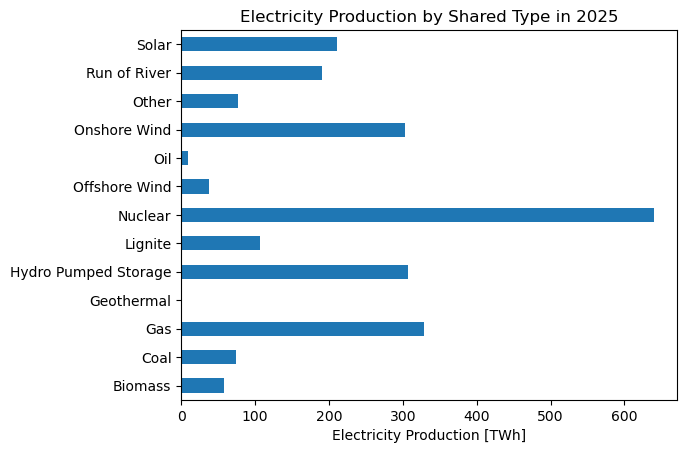

In [3]:
historic_entsoe_2025 = pd.read_csv(
    "entsoe_generation_2025/generation_2025_annual_by_area_type.csv",
)


historic_entsoe_2025 = historic_entsoe_2025[
    (~historic_entsoe_2025["production_type"].str.contains(r"\|"))
    |
    (historic_entsoe_2025["production_type"].str.endswith("Actual Aggregated"))
]

# strip suffix
historic_entsoe_2025["production_type"] = (
    historic_entsoe_2025["production_type"]
    .str.replace(" \\| Actual Aggregated", "", regex=True)
)

# aggregate by area and production type
historic_entsoe_2025 = (
    historic_entsoe_2025
    .groupby(["area", "production_type"], as_index=False)
    .agg({"generation_twh": "sum"})
)
# convert to dataframe
historic_entsoe_2025 = historic_entsoe_2025.groupby("production_type")["generation_twh"].sum().to_frame().reset_index()

matched_data_dictionary = {
    'Offshore Wind': ['Wind Offshore', 'offwind-ac', 'offwind-dc', 'offwind-float'],
    'Onshore Wind': ['onwind', 'Wind Onshore'],
    'Solar' : ['Solar', 'solar', 'solar-hsat', 'solar rooftop'],
    'Nuclear': ['Nuclear', 'nuclear'], 
    'Run of River': ['Hydro Run-of-river and poundage', 'ror'],
    'Hydro Pumped Storage': ['Hydro Pumped Storage', 'PHS', 'hydro', 'Hydro Water Reservoir', ],
    'Coal': ['coal', 'Fossil Hard coal'], 
    'Lignite': ['Fossil Brown coal/Lignite', 'lignite'],
    'Gas': ['Fossil Gas', 'gas', 'Fossil Coal-derived gas', 'CCGT', 'OCGT'],
    'Geothermal': ['Geothermal', 'geothermal'],
    'Biomass': ['urban decentral heat vent', 'urban central heat vent', 'Biomass', 'Waste', 'rural heat vent', 'biomass'],
    'Other': ['Other', 'Other renewable', 'Marine'],
    'Oil': ['oil', 'Oil', 'Fossil Oil', 'Fossil Oil shale', 'Fossil Peat', 'oil primary']
    }

alias_to_shared = {
    alias: shared
    for shared, aliases in matched_data_dictionary.items()
    for alias in aliases
}

for type in historic_entsoe_2025["production_type"].unique():
    if type not in alias_to_shared:
        print(f"WARNING: No shared category for production type '{type}'")
historic_entsoe_2025["shared_production_type"] = historic_entsoe_2025["production_type"].map(alias_to_shared)

# bar plot of the result
df = historic_entsoe_2025.groupby("shared_production_type")["generation_twh"].sum()
df.plot.barh(xlabel="Electricity Production [TWh]", ylabel="", title="Electricity Production by Shared Type in 2025")

In [4]:
def electric_supply_from_the_sector_models(network_choice):
    #gets the total supply from the various carriers to the electric sector of the model, where applicable 
    ##the renewable generators connect directly to the AC buses 
    ## the conventional links deliver a certain amount of energy to the AC buses -- in the sector models the big loads are connected to the low voltage buses
  network = network_choice
  supply = {}

    #renewables 
  renewable_carriers = ['solar', 'offwind-dc', 'onwind',
       'offwind-ac', 'offwind-float', 'solar-hsat', 'ror', 'solar rooftop', 'hydro', 'ror', 'PHS']
      #generators 
  renewable_generators_by_carrier = network.generators[network.generators.carrier.isin(renewable_carriers)].index
  renewable_generators_by_carrier 
  renewables_dispatch = network.generators_t.p[renewable_generators_by_carrier]
  renewables_dispatch = renewables_dispatch.T
  renewables_dispatch=renewables_dispatch.groupby(network.generators.carrier).sum()
  renewables_dispatch = renewables_dispatch * network.snapshot_weightings.objective[0] #MW --> MWh 
  renewables_dispatch = renewables_dispatch.sum(axis=1)
    #low carbon carriers
  low_carbon_carriers = ['nuclear', 'geothermal']
  low_carbon_carriers = network.generators[network.generators.carrier.isin(low_carbon_carriers)].index
  low_carbon_dispatch = network.generators_t.p[low_carbon_carriers]
  low_carbon_dispatch = low_carbon_dispatch * network.snapshot_weightings.objective[0] #MW --> MWh
  low_carbon_dispatch = low_carbon_dispatch.T
  low_carbon_dispatch = low_carbon_dispatch.groupby(network.generators.carrier).sum()
  low_carbon_dispatch = low_carbon_dispatch.sum(axis=1)
  low_carbon_dispatch
    #conventional carriers = 
  conventional_carriers = ['coal', 'lignite', 'CCGT', 'OCGT', 'oil', "urban central solid biomass CHP", "urban central CHP", "urban central solid biomass CHP CC", "urban central CHP CC", 'H2 turbine', 'H2 Fuel Cell'] #biomass is technically low carbon, but CHP is given in links. biomass CHP only in urban central
  conventional_links = network.links[network.links.carrier.isin(conventional_carriers)].index
  conventional_links = network.links_t.p1[conventional_links]#power delivered to the end bus, which is always the big electric buses 
  conventional_links = conventional_links * network.snapshot_weightings.objective[0] * -1 #MW --> MWh, and multiplied by netgative one because contributing power to those buses
  conventional_links = conventional_links.T
  conventional_links = conventional_links.groupby(network.links.carrier).sum()
  conventional_links = conventional_links.sum(axis=1)
  conventional_links
  
  #hydro
  hydro_dispatch = network.storage_units_t.p.T.groupby(network.storage_units.carrier).sum().sum(axis=1) #storage units are just hydro and phs 
  hydro_dispatch = hydro_dispatch * network.snapshot_weightings.objective[0] #MW --> MWh



  dispatch_dict = {k: v for s in [renewables_dispatch, low_carbon_dispatch, conventional_links, hydro_dispatch] for k, v in s.items()}
  return dispatch_dict 

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.2.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, sub_networks


<Axes: title={'center': 'Electricity Production by Shared Type in 2025'}, xlabel='Electricity Production [TWh]'>

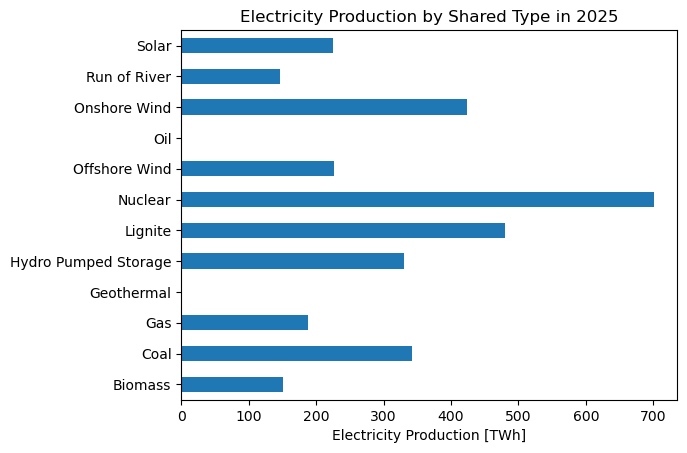

In [5]:
test_BAU_network_no_flex_2025 = pypsa.Network(
    '~/Repos/pypsa-eur/results/networks/base_s_39_elec_.nc'
)

# pypsa_gen = electric_supply_from_the_sector_models(test_BAU_network_no_flex_2025)

# pypsa_gen = pd.DataFrame.from_dict(pypsa_gen, orient='index', columns=['generation_mwh']).reset_index().rename(columns={'index': 'carrier'})
# pypsa_gen["generation_twh"] = pypsa_gen["generation_mwh"] / 1e6
# pypsa_gen["shared_carrier"] = pypsa_gen["carrier"].map(alias_to_shared)
# pypsa_gen.groupby("shared_carrier")["generation_twh"].sum().plot.barh(
#     xlabel="Electricity Production [TWh]", ylabel="", title="Electricity Production by Shared Type in 2025 (from PyPSA)"
# )

elec_supply = (
    test_BAU_network_no_flex_2025.statistics.supply(
        components=["Generator", "Link", "StorageUnit"],
        bus_carrier=["AC",],
        groupby="carrier",
        aggregate_across_components=True,
        groupby_time="sum",
        nice_names=False,
        drop_zero=True,
    )
    .rename("supply_mwh")
    .sort_values(ascending=False)
)

elec_supply = elec_supply.reset_index()
elec_supply['supply_twh'] = elec_supply['supply_mwh'] / 1e6
elec_supply['shared_carrier'] = elec_supply['carrier'].map(alias_to_shared)
elec_supply.groupby("shared_carrier")["supply_twh"].sum().plot.barh(
    xlabel="Electricity Production [TWh]", ylabel="", title="Electricity Production by Shared Type in 2025"
)


<Axes: title={'center': 'Electricity Production by Shared Type in 2025'}, xlabel='Electricity Production [TWh]'>

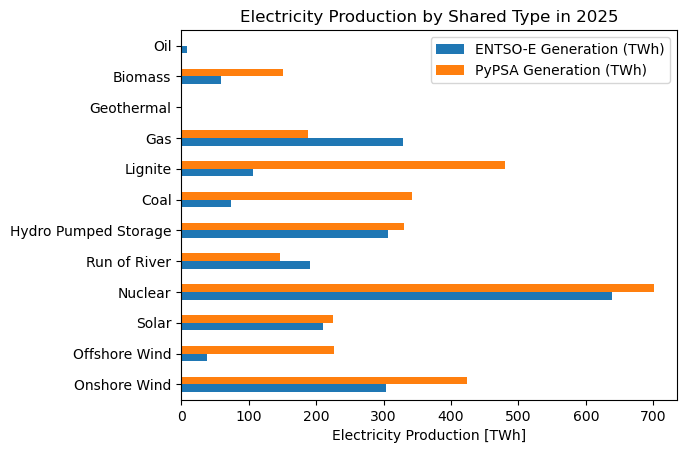

In [6]:
# merge dfs 
order = [
    "Oil",
    "Other",
    "Biomass",
    "Geothermal",
    "Gas",
    "Lignite",
    "Coal",
    "Hydro Pumped Storage",
    "Run of River",
    "Nuclear",
    "Solar",
    "Offshore Wind",
    "Onshore Wind",]
rev_order = list(reversed(order))
(df
    .to_frame().reset_index()
    .merge(
        elec_supply.groupby("shared_carrier")["supply_twh"].sum().reset_index(),
        left_on="shared_production_type",
        right_on="shared_carrier", how="outer")
    .rename(columns={"generation_twh": "ENTSO-E Generation (TWh)", "supply_twh": "PyPSA Generation (TWh)"})
    # sort by specified order of shared types
    .set_index("shared_carrier")
    .reindex(rev_order)
    .dropna()
    .plot.barh(
        x="shared_production_type",
        y=["ENTSO-E Generation (TWh)", "PyPSA Generation (TWh)"],
        xlabel="Electricity Production [TWh]",
        ylabel="",
        title="Electricity Production by Shared Type in 2025",
    )
)
